In [1]:
import torch
from numpy.f2py.auxfuncs import throw_error
from sklearn.metrics import r2_score, mean_squared_error
from torch import nn
from torch.nn import functional as F
from torch.nn import Linear, ReLU, Sequential, RNN
from torch.optim import Adam, SGD
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import random
from sklearn.model_selection import train_test_split

In [2]:
# Defining device for training, x, y and f(x, y)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X, y = torch.arange(0, 10, 0.1), torch.arange(0, 10, 0.1)
XX, yy = torch.meshgrid(X, y, indexing='ij')

X_cords = XX.flatten()
y_cords = yy.flatten()

z = 0.5 * X_cords ** 2 - 2 * y_cords ** 2 + X_cords - 1

X_y = torch.cat((X_cords.unsqueeze(1), y_cords.unsqueeze(1)), dim=1)
X_y_train, X_y_test, z_train, z_test = [i.to(device) for i in train_test_split(X_y, z, test_size=0.2, random_state=42)]
print(f'Device: {device}')
len(X_y_train), len(X_y_test), X_y[:5]

Device: cpu


(8000,
 2000,
 tensor([[0.0000, 0.0000],
         [0.0000, 0.1000],
         [0.0000, 0.2000],
         [0.0000, 0.3000],
         [0.0000, 0.4000]]))

In [3]:
X_y_train.shape, z_train.shape, z_test.shape

(torch.Size([8000, 2]), torch.Size([8000]), torch.Size([2000]))

In [4]:
# Feed forward backpropagation model
class FeedForward(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.mean_squared_error = None
        self.r2_score = None
        self.modules_seq = Sequential(Linear(2, hidden_dim), ReLU(), Linear(hidden_dim, 1))

    def forward(self, input_X_y):
        return self.modules_seq(input_X_y)

# Cascade forward backpropagation model
class CascadeForward(nn.Module):
    def __init__(self, num_of_dim, hidden_dim):
        super().__init__()
        self.mean_squared_error = None
        self.r2_score = None
        self.num_of_dim = num_of_dim
        self.hidden_layer_1 = nn.Linear(2, hidden_dim)
        if num_of_dim == 1:
            self.output = nn.Linear(2 + hidden_dim, 1)
        elif num_of_dim == 2:
            self.hidden_layer_2 = nn.Linear(2 + hidden_dim, hidden_dim)
            self.output = nn.Linear(2 + hidden_dim + hidden_dim, 1)
        else:
            throw_error('num_of_dim must be 1 or 2')

    def forward(self, input_X_y):
        h1_layer_out = F.relu(self.hidden_layer_1(input_X_y))
        if self.num_of_dim == 1:
            output_in = torch.cat((input_X_y, h1_layer_out), dim=1)
            return self.output(output_in)

        elif self.num_of_dim == 2:
            h2_layer_in = torch.cat((input_X_y, h1_layer_out), dim=1)
            h2_layer_out = F.relu(self.hidden_layer_2(h2_layer_in))

            output_in = torch.cat((input_X_y, h1_layer_out, h2_layer_out), dim=1)
            return self.output(output_in)

        else:
            throw_error('num_of_dim must be 1 or 2')
            return None

class ElmanBackprop(nn.Module):
    def __init__(self, hidden_size, num_layers=1):
        super().__init__()
        self.mean_squared_error = None
        self.r2_score = None
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.elman_layer = RNN(input_size=2, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, nonlinearity='tanh')
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, input_X_y):
        input_seq = input_X_y.unsqueeze(1)
        out, _ = self.elman_layer(input_seq)

        last_time_step_out = out[:, -1, :]
        final_prediction = self.output_layer(last_time_step_out)

        return final_prediction

In [5]:
def training_loop(model, input_train, input_test, output_train, output_test, num_epochs, model_name):
    optimizer = Adam(model.parameters(), lr=0.03)
    criterion = nn.MSELoss().to(device)

    train_loss_lt = []
    test_loss_lt = []
    epoch_count = []

    for epoch in range(num_epochs):
        model.train()
        train_pred = model(input_train)
        loss = criterion(train_pred, output_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.inference_mode():
            test_pred = model(input_test)
            test_loss = criterion(test_pred, output_test)

            if epoch % 100 == 0:
                epoch_count.append(epoch)
                train_loss_lt.append(loss.item())
                test_loss_lt.append(test_loss.item())
                print(f'Epoch: {epoch}, Train Loss: {loss.item()}, Test Loss: {test_loss.item()}')

            if test_loss.item() < 3:
                break

    model.mean_squared_error = mean_squared_error(output_test.cpu(), test_pred.cpu())
    model.r2_score = r2_score(output_test.cpu(), test_pred.cpu())

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(epoch_count, train_loss_lt, label="Train loss")
    ax.plot(epoch_count, test_loss_lt, label="Test loss")
    ax.set_title(f"Графік передбачень тренувальних та тестових даних\nвідповідно до епох, модель: {model_name}")
    ax.set_yscale('log')
    formatter = mticker.ScalarFormatter()
    ax.yaxis.set_major_formatter(formatter)
    # ax.yaxis.set_minor_formatter(formatter)
    ax.set_ylabel("Loss")
    ax.set_xlabel("Epochs")
    ax.legend()
    plt.show()

Epoch: 0, Train Loss: 5767.30810546875, Test Loss: 5478.37451171875
Epoch: 100, Train Loss: 252.67691040039062, Test Loss: 253.18386840820312
Epoch: 200, Train Loss: 145.85360717773438, Test Loss: 144.57266235351562
Epoch: 300, Train Loss: 84.11219024658203, Test Loss: 82.87053680419922
Epoch: 400, Train Loss: 49.91094207763672, Test Loss: 48.99697494506836
Epoch: 500, Train Loss: 30.573259353637695, Test Loss: 30.115846633911133
Epoch: 600, Train Loss: 19.902219772338867, Test Loss: 19.794591903686523
Epoch: 700, Train Loss: 13.066648483276367, Test Loss: 12.915698051452637
Epoch: 800, Train Loss: 9.195871353149414, Test Loss: 9.141464233398438
Epoch: 900, Train Loss: 7.4107184410095215, Test Loss: 7.414834976196289
Epoch: 1000, Train Loss: 6.344381809234619, Test Loss: 6.36108922958374
Epoch: 1100, Train Loss: 5.629644393920898, Test Loss: 5.662414073944092
Epoch: 1200, Train Loss: 5.119998931884766, Test Loss: 5.142940521240234
Epoch: 1300, Train Loss: 4.728728294372559, Test Loss: 

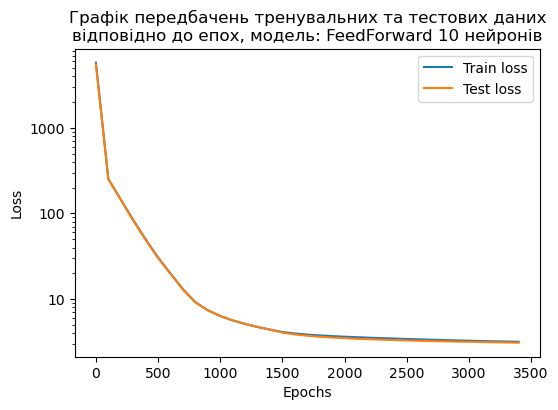

Mean Squared Error: 3.0815181732177734, R2 Error: 0.9991812705993652


In [6]:
# Model with 10 neurons in a hidden layer
model_feed_forward_0 = FeedForward(hidden_dim=10).to(device)
training_loop(model_feed_forward_0, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 3500, 'FeedForward 10 нейронів')
print(f'Mean Squared Error: {model_feed_forward_0.mean_squared_error}, R2 Error: {model_feed_forward_0.r2_score}')

Epoch: 0, Train Loss: 5905.412109375, Test Loss: 5543.0556640625
Epoch: 100, Train Loss: 164.3766632080078, Test Loss: 163.08621215820312
Epoch: 200, Train Loss: 95.8997802734375, Test Loss: 95.43091583251953
Epoch: 300, Train Loss: 51.65580749511719, Test Loss: 50.70806884765625
Epoch: 400, Train Loss: 23.63201141357422, Test Loss: 23.133136749267578
Epoch: 500, Train Loss: 11.924211502075195, Test Loss: 11.73100757598877
Epoch: 600, Train Loss: 7.334928512573242, Test Loss: 7.22212553024292
Epoch: 700, Train Loss: 5.361899375915527, Test Loss: 5.287140369415283
Epoch: 800, Train Loss: 4.36738920211792, Test Loss: 4.321977615356445
Epoch: 900, Train Loss: 3.784648895263672, Test Loss: 3.75846004486084
Epoch: 1000, Train Loss: 3.398163080215454, Test Loss: 3.3792309761047363
Epoch: 1100, Train Loss: 3.102830410003662, Test Loss: 3.0851492881774902


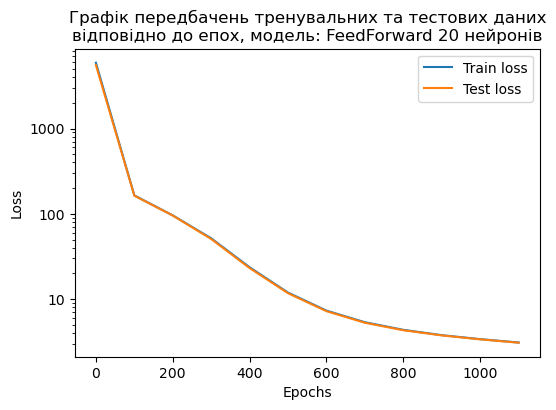

Mean Squared Error: 2.9988808631896973, R2 Error: 0.9992032647132874


In [7]:
# Creating a new model, but with more neurons in a hidden layer
model_feed_forward_1 = FeedForward(hidden_dim=20).to(device)
training_loop(model_feed_forward_1, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 3500, 'FeedForward 20 нейронів')
print(f'Mean Squared Error: {model_feed_forward_1.mean_squared_error}, R2 Error: {model_feed_forward_1.r2_score}')

Epoch: 0, Train Loss: 5827.06494140625, Test Loss: 5404.8369140625
Epoch: 100, Train Loss: 153.5442352294922, Test Loss: 149.3250732421875
Epoch: 200, Train Loss: 65.74330139160156, Test Loss: 64.56729888916016
Epoch: 300, Train Loss: 37.01077651977539, Test Loss: 36.096641540527344
Epoch: 400, Train Loss: 24.192367553710938, Test Loss: 23.480941772460938
Epoch: 500, Train Loss: 19.139503479003906, Test Loss: 18.417924880981445
Epoch: 600, Train Loss: 16.677108764648438, Test Loss: 16.079187393188477
Epoch: 700, Train Loss: 15.327261924743652, Test Loss: 14.795907020568848
Epoch: 800, Train Loss: 7.004146099090576, Test Loss: 6.942706108093262
Epoch: 900, Train Loss: 4.056742191314697, Test Loss: 4.173853397369385


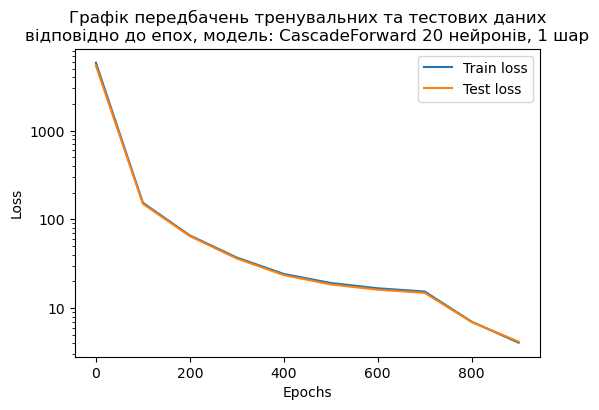

Mean Squared Error: 2.9950413703918457, R2 Error: 0.9992042779922485


In [8]:
model_cascade_forward_0 = CascadeForward(1, 20).to(device)
training_loop(model_cascade_forward_0, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 3500, 'CascadeForward 20 нейронів, 1 шар')
print(f'Mean Squared Error: {model_cascade_forward_0.mean_squared_error}, R2 Error: {model_cascade_forward_0.r2_score}')

Epoch: 0, Train Loss: 5833.9755859375, Test Loss: 5453.2080078125
Epoch: 100, Train Loss: 115.49801635742188, Test Loss: 113.4561767578125
Epoch: 200, Train Loss: 21.75374412536621, Test Loss: 21.023637771606445
Epoch: 300, Train Loss: 9.99843978881836, Test Loss: 9.838216781616211


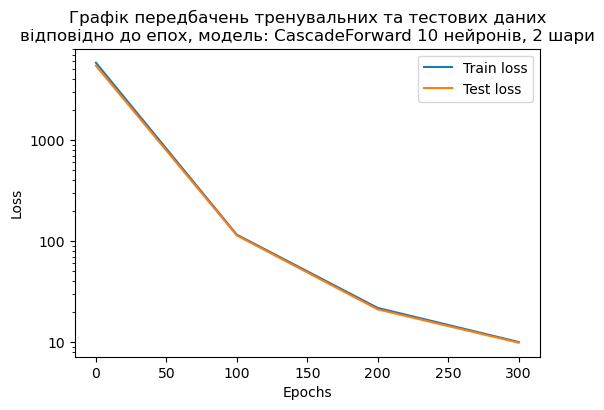

Mean Squared Error: 2.9534120559692383, R2 Error: 0.999215304851532


In [9]:
model_cascade_forward_1 = CascadeForward(2, 10).to(device)
training_loop(model_cascade_forward_1, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 3500, 'CascadeForward 10 нейронів, 2 шари')
print(f'Mean Squared Error: {model_cascade_forward_1.mean_squared_error}, R2 Error: {model_cascade_forward_1.r2_score}')

Epoch: 0, Train Loss: 5844.8681640625, Test Loss: 5553.68310546875
Epoch: 100, Train Loss: 2338.360107421875, Test Loss: 2235.85888671875
Epoch: 200, Train Loss: 1019.4445190429688, Test Loss: 985.1055908203125
Epoch: 300, Train Loss: 493.7895812988281, Test Loss: 482.8932800292969
Epoch: 400, Train Loss: 261.6935119628906, Test Loss: 258.22119140625
Epoch: 500, Train Loss: 149.9174346923828, Test Loss: 148.43614196777344
Epoch: 600, Train Loss: 91.60669708251953, Test Loss: 90.67450714111328
Epoch: 700, Train Loss: 59.143836975097656, Test Loss: 58.21977615356445
Epoch: 800, Train Loss: 40.009517669677734, Test Loss: 38.93258285522461
Epoch: 900, Train Loss: 28.072872161865234, Test Loss: 26.788362503051758
Epoch: 1000, Train Loss: 20.37566375732422, Test Loss: 18.96525764465332
Epoch: 1100, Train Loss: 16.97821044921875, Test Loss: 16.325942993164062
Epoch: 1200, Train Loss: 11.503501892089844, Test Loss: 10.13783073425293
Epoch: 1300, Train Loss: 8.903695106506348, Test Loss: 7.6769

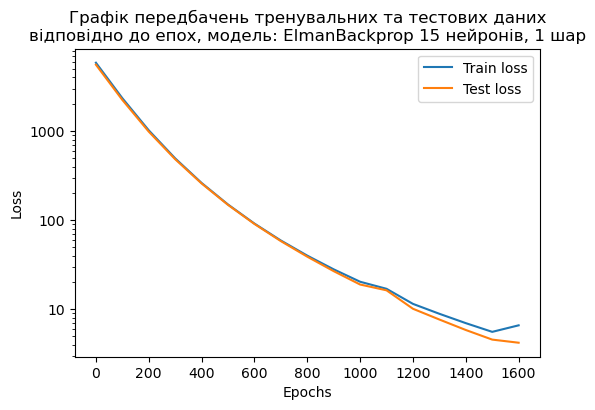

Mean Squared Error: 2.998199224472046, R2 Error: 0.9992034435272217


In [10]:
# Elman model with 15 neurons in a hidden layer
model_elman_backprop_0 = ElmanBackprop(15, 1).to(device)
training_loop(model_elman_backprop_0, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 3500, 'ElmanBackprop 15 нейронів, 1 шар')
print(f'Mean Squared Error: {model_elman_backprop_0.mean_squared_error}, R2 Error: {model_elman_backprop_0.r2_score}')

Epoch: 0, Train Loss: 5879.025390625, Test Loss: 5604.6015625
Epoch: 100, Train Loss: 4050.23486328125, Test Loss: 3874.209228515625
Epoch: 200, Train Loss: 2915.763427734375, Test Loss: 2797.322265625
Epoch: 300, Train Loss: 2137.98291015625, Test Loss: 2058.271484375
Epoch: 400, Train Loss: 1589.7733154296875, Test Loss: 1535.9945068359375
Epoch: 500, Train Loss: 1195.7879638671875, Test Loss: 1159.02294921875
Epoch: 600, Train Loss: 908.365234375, Test Loss: 883.642333984375
Epoch: 700, Train Loss: 696.7631225585938, Test Loss: 684.1420288085938
Epoch: 800, Train Loss: 536.4708862304688, Test Loss: 526.8203125
Epoch: 900, Train Loss: 417.5126953125, Test Loss: 411.6513977050781
Epoch: 1000, Train Loss: 331.27764892578125, Test Loss: 324.07763671875
Epoch: 1100, Train Loss: 258.7414245605469, Test Loss: 256.5573425292969
Epoch: 1200, Train Loss: 207.06593322753906, Test Loss: 205.2125244140625
Epoch: 1300, Train Loss: 165.31956481933594, Test Loss: 164.483642578125
Epoch: 1400, Train

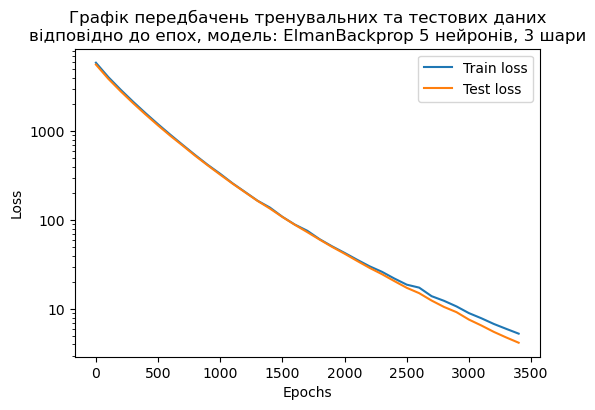

Mean Squared Error: 4.554620742797852, R2 Error: 0.99878990650177


In [11]:
# Elman model with 15 neurons in a hidden layer
model_elman_backprop_1 = ElmanBackprop(5, 3).to(device)
training_loop(model_elman_backprop_1, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 3500, 'ElmanBackprop 5 нейронів, 3 шари')
print(f'Mean Squared Error: {model_elman_backprop_1.mean_squared_error}, R2 Error: {model_elman_backprop_1.r2_score}')